# Description

This notebook cotains a model to predict the daily average load for the next 5 weeks in multi steps. The features are detailed in days.

# Load Libs

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

import pendulum

from functions import (load_data,
                        Preprocessor,
                        create_target_df,
                        Baseline,
                        Window_Generator,
                        compile_and_fit,
                        learning_curves,
                        plot_pred,
                        plot_res,
                        metrics_semana,
                        baseline_metrics) 


In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
regiao = 'SUDESTE'
SEED = 42

batch_size = 32
# number of week to be predicted
predict_weeks = 1
# target days to sum into weeks
target_period = 7*predict_weeks
# number of weeks in the window
n_weeks_ws = 5
# window size in days for each row
window_size = 7*n_weeks_ws

filepath = 'Models/Model_v3.h5'


np.random.seed(SEED)
tf.random.set_seed(SEED)

# períodograma; 
autocorrelação total e parcial


# Load data

In [4]:
df_20XX = load_data(start=2009, end=2022)
df_20XX.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,NORTE,2009-01-01,3330.302917
1,NE,NORDESTE,2009-01-01,6138.174583
2,S,SUL,2009-01-01,6085.486507
3,SE,SUDESTE,2009-01-01,22893.838750
4,N,NORTE,2009-01-02,3480.832083


# Preprocess data

In [5]:
pp = Preprocessor(regiao='SUDESTE')
df = pp.fit_transform(df_20XX)

No missing NaN.

No missing days in the series


# Split Data

In [6]:
train_df, val_df, test_df = pp.split_time(df=df,
                                            folds = 3,
                                            val_start=0.7, 
                                            test_start=0.9)

First day of train_df: 2009-01-02 00:00:00
First day of val_df: 2018-03-30 00:00:00
First day of test_df: 2020-11-20 00:00:00


# Target

In [7]:
df_target = create_target_df(df, baseline_size=5)
df_target.tail(6)

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo,Média Móvel
semana,,,,,,,,,
683,41838.713446,42354.806815,42908.934060,43796.079827,45429.410685,2022-02-04,Friday,516.093369,41195.864911
684,42354.806815,42908.934060,43796.079827,45429.410685,44590.574107,2022-02-11,Friday,554.127244,41920.741824
685,42908.934060,43796.079827,45429.410685,44590.574107,NaN,2022-02-18,Friday,887.145768,42568.066937
686,43796.079827,45429.410685,44590.574107,NaN,NaN,2022-02-25,Friday,1633.330857,42662.702388
687,45429.410685,44590.574107,NaN,NaN,NaN,2022-03-04,Friday,-838.836577,42535.193224
688,44590.574107,NaN,NaN,NaN,NaN,2022-03-11,Friday,NaN,43265.588967


# Process Data 

In [10]:
class Window_Generator(BaseEstimator):
    
    def __init__(self, target_period, window_size, batch_size,shuffle_buffer,
                 regiao = regiao, sazo_weeks=2, SEED=SEED, how = 'dia para semana'):
        self.target_period = target_period
        self.window_size = window_size
        self.batch_size = batch_size
        self.shuffle_buffer = shuffle_buffer
        self.regiao = regiao
        self.SEED = SEED
        self.how = how
        self.sazo_weeks = sazo_weeks
        assert self.how in ['dia para semana', 'sazonalidade anual','autorregressivo']
        assert self.window_size % 7 == 0, "window_size deve ser divisível por 7"
    pass
    
    def generate_data_week(self, df):
        """Generate a list with the same index as the window features with the first
            day of the first week of the target
        Returns:
            data_week: first day of the first target week
        """
        df = df.copy()
        # if df['din_instante'].iloc[0].day_name() != 'Friday':
        #     # get next friday - begins the operative week
        #     df = Preprocessor(regiao=self.regiao).go_to_friday(df)
        # groupby object by week and then by day
        df_grouped = df[self.window_size:].groupby(by=['semana'])['din_instante']
        # get first day of each week and  removes the last 4 rows 
        # because we want to save the first day of the first target week
        # so we drop the last target 4 weeks 
        return df_grouped.min()[:-4]
    
    def map_data(self, dataset):
        """Defines how the data will be processed into features and target.
        If self.how = 'dia para semana', the features will be in daily load of window_size lenght.
        If self.how = 'sazonalidade anual', the features will be the last 'sazo_weeks' weeks and the same week from last year.
        if self.how = 'autorregressivo', the features are deteiled in days until the last 5 week (that becomes 1 input each as the weekly average load). This enables multi-step prediction.

        Args:
            dataset (tf.data.Dataset): windowed dataset

        Returns:
            tf.data.Dataset: dataset processed into features and targets
        """
        if self.how == 'dia para semana':
            """inputs in daily average load, targets in weekly average load"""
            assert self.target_period == 35, f"targe_period = {self.target_period}, deve ser igual a 35 (5 semanas)"
            dataset = dataset.map(lambda window:(window[:-self.target_period],   #features
                                        [tf.math.reduce_sum(window[-35:-28])/7, # first target week
                                        tf.math.reduce_sum(window[-28:-21])/7, # second target week
                                        tf.math.reduce_sum(window[-21:-14])/7, # third target week
                                        tf.math.reduce_sum(window[-14:-7])/7,  # fourth target week
                                        tf.math.reduce_sum(window[-7:])/7]      # fifith target week
                                                )
                                 )
        
        if self.how == 'sazonalidade anual':
            """ the inputs are the daily load of the same week in the year before and in the last sazo_weeks from the time window"""
            assert self.window_size >= 365, "window size menor que 365 dias, não é possível usar how = 'sazonalidade anual'"
            assert self.target_period == 35, f"targe_period = {self.target_period}, deve ser igual a 35 (5 semanas)"
            dataset = dataset.map(lambda window:(tf.concat(
                values=
                    [
                    window[-364-self.target_period:-357-self.target_period],     # week in the year before
                    window[-(self.sazo_weeks*7)-self.target_period:-self.target_period] # last weeks
                    ], 
                axis=-1),   #features
                                    [tf.math.reduce_sum(window[-35:-28])/7, # first target week
                                    tf.math.reduce_sum(window[-28:-21])/7, # second target week
                                    tf.math.reduce_sum(window[-21:-14])/7, # third target week
                                    tf.math.reduce_sum(window[-14:-7])/7,  # fourth target week
                                    tf.math.reduce_sum(window[-7:])/7]      # fifith target week
                    )
                                 )

        if self.how == 'autorregressivo':
            """ for multi-step forecasting. target = next week; inputs = last five weeks as weekly average load, before that, in daily load"""
            assert self.target_period == 7, f"target_periodo = {self.target_period}, deve ser igual = 7 (dias)"
            assert self.window_size >=35, "window_size menor que 5 semanas"
            
            dataset = dataset.map(lambda window:(tf.concat(values=[
                window[:-35-self.target_period], # features in days before the last five weeks
                tf.reshape(tf.math.reduce_mean(window[-5*7-self.target_period:-4*7-self.target_period],axis=0),shape=[-1]), # fifth last input week
                tf.reshape(tf.math.reduce_mean(window[-4*7-self.target_period:-3*7-self.target_period],axis=0),shape=[-1]), # forth last input week
                tf.reshape(tf.math.reduce_mean(window[-3*7-self.target_period:-2*7-self.target_period],axis=0),shape=[-1]), # third last input week
                tf.reshape(tf.math.reduce_mean(window[-2*7-self.target_period:-7-self.target_period],axis=0),shape=[-1]),  # second last input week
                tf.reshape(tf.math.reduce_mean(window[-7-self.target_period:-self.target_period],axis=0),shape=[-1]) # last input week
                                ],
                                                            axis=-1),
                                        # target - the weekly average load of one week 
                                        tf.math.reduce_mean(window[-self.target_period:],axis=0)
                                                )
                                )

        return dataset

    def transform(self, df, shuffle=True):
        """Transform a preprocessed dataframe in a windowed dataset
        Returns:
            dataset: a windowed tensorflow.dataset with window_size timesteps for features
                     and the average daily load for the next five weeks as targets
        """
        df = df.copy()
        data_week = self.generate_data_week(df)
        series = df['val_cargaenergiamwmed']
        # generate tf.dataset
        dataset = tf.data.Dataset.from_tensor_slices(series)
        
        # create windows 
        dataset = dataset.window(self.window_size + self.target_period, shift=7, drop_remainder=True)
        # make sure every window is the same size / clip NaN at the end
        dataset = dataset.flat_map(lambda window: window.batch(self.window_size + self.target_period))
        if shuffle:
            # randomly shuffles the windows instances in the dataset 
            dataset = dataset.shuffle(self.shuffle_buffer,seed=self.SEED)
        # separates features and target and take the average of the target days by week
        dataset = self.map_data(dataset)

        # batch and prefetch
        dataset = dataset.batch(batch_size).prefetch(1)
        return dataset, data_week

In [12]:
wd = Window_Generator(batch_size = batch_size, 
                     window_size = 5*7,
                     shuffle_buffer = 20, 
                     target_period = 7, 
                     how = 'autorregressivo',
                     SEED = SEED)


# dataset to training
train_dataset, train_data_week = wd.transform(df = train_df, shuffle=True)

# dataset for performance evaluation
train_pred_dataset, train_pred_data_week = wd.transform(df = train_df, shuffle=False)
val_dataset, val_data_week = wd.transform(df = val_df, shuffle=False)
test_dataset, test_data_week = wd.transform(df = test_df, shuffle=False)



date_list = [train_pred_data_week,val_data_week,test_data_week]

## Check data processing:

In [13]:
for x1, y1 in  train_pred_dataset:
    x2=x1
    y2=y1
    
x1[-1]

<tf.Tensor: shape=(5,), dtype=float64, numpy=
array([39466.50986905, 39035.26317262, 40687.24772619, 40377.54954762,
       40723.76704167])>

In [20]:
df_target[np.round(df_target['Semana 1'],2)==np.round(x1[-1][0],2)]

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo,Média Móvel
semana,,,,,,,,,
476,39466.509869,39035.263173,40687.247726,40377.549548,40723.767042,2018-02-16,Friday,-431.246696,39389.608577


In [21]:
df_target.loc[train_pred_data_week.index]

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo,Média Móvel
semana,,,,,,,,,
5,32150.677321,31443.203095,29987.839524,33188.868750,33265.600952,2009-02-06,Friday,-707.474226,30071.930274
6,31443.203095,29987.839524,33188.868750,33265.600952,32117.119286,2009-02-13,Friday,-1455.363571,30994.752976
7,29987.839524,33188.868750,33265.600952,32117.119286,31351.439048,2009-02-20,Friday,3201.029226,31077.555643
8,33188.868750,33265.600952,32117.119286,31351.439048,31408.691667,2009-02-27,Friday,76.732202,30986.289631
9,33265.600952,32117.119286,31351.439048,31408.691667,31249.352083,2009-03-06,Friday,-1148.481667,31632.587762
...,...,...,...,...,...,...,...,...,...
473,39465.454363,37986.088554,37987.057208,39466.509869,39035.263173,2018-01-26,Friday,-1479.365810,37935.695594
474,37986.088554,37987.057208,39466.509869,39035.263173,40687.247726,2018-02-02,Friday,0.968655,38643.528977
475,37987.057208,39466.509869,39035.263173,40687.247726,40377.549548,2018-02-09,Friday,1479.452661,39183.459954


In [15]:
df[df['val_cargaenergiamwmed'] == x2[-1][-6]]

InvalidArgumentError: slice index -1 of dimension 0 out of bounds. [Op:StridedSlice] name: strided_slice/

In [16]:
y2[-1]

<tf.Tensor: shape=(), dtype=float64, numpy=39625.374702382855>

In [17]:
df_target[df_target['Semana 1'] == y2[-1]]

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo,Média Móvel
semana,,,,,,,,,
481,39625.374702,37628.254131,37649.552381,35905.330887,35702.304946,2018-03-23,Friday,-1997.120571,40058.067471


In [18]:
c=0
for x,y in train_pred_dataset:
  #print('x=', x)
  #print('y=', y)
  c +=1
  print(x.shape,y.shape)
  break
#print(c*batch_size)

(32, 5) (32,)


# train model and predict

In [103]:
# LSTM
model = tf.keras.models.Sequential([
    tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis = -1), input_shape=[None]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LSTM(32, return_sequences=False, activation ='tanh'),
    tf.keras.layers.Dense(1),
    tf.keras.layers.Lambda(lambda x: x * 10000.0)
    ])


history = compile_and_fit(model, epochs = 150, 
                          data=train_dataset, 
                          val_data = val_dataset,
                          optimizer = tf.optimizers.Adam(learning_rate=0.001),
                          patience = 100,
                          filepath = filepath)

In [209]:
def predict_load(pred_dataset,window_size=5):
    window_pred= []
    # loop the input windows
    for window_loop, target in pred_dataset:
        # make a copy of the window to edit
        window = window_loop
        # loop the time steps in a input window
        for step in range(0,5):
            # predict using the last 5 inputs
            forecast = model.predict(window[:,-window_size:])
            # append the prediction to the input window
            window = tf.concat(values=[window,forecast], axis=-1)[:,-window_size:]
        window_pred.append(window)
    return window_pred

def unbatch_pred(window_pred):
    # unbatch
    numpy_pred = [x.numpy() for x in window_pred]  
    pred = numpy_pred[0]
    for batch in numpy_pred[1:]:
        for item in batch:
            pred = np.append(pred,item).reshape([-1,5])
    return pred[:-4]

In [211]:
train_pred = predict_load(train_pred_dataset,window_size=5)
val_pred = predict_load(val_dataset,window_size=5)
test_pred = predict_load(test_dataset,window_size=5)

pred_list = [unbatch_pred(train_pred), unbatch_pred(val_pred),unbatch_pred(test_pred)]

In [189]:
df_target.head()

,Semana 1,Semana 2,Semana 3,Semana 4,Semana 5,Data,dia semana,Resíduo,Média Móvel
semana,,,,,,,,,
0,27536.563810,31029.189762,30444.169583,29957.378095,31392.350119,2009-01-02,Friday,3492.625952,NaN
1,31029.189762,30444.169583,29957.378095,31392.350119,32150.677321,2009-01-09,Friday,-585.020179,NaN
2,30444.169583,29957.378095,31392.350119,32150.677321,31443.203095,2009-01-16,Friday,-486.791488,NaN
3,29957.378095,31392.350119,32150.677321,31443.203095,29987.839524,2009-01-23,Friday,1434.972024,NaN
4,31392.350119,32150.677321,31443.203095,29987.839524,33188.868750,2009-01-30,Friday,758.327202,NaN


In [191]:
c=0
for x,y in train_pred_dataset:
  #print('x=', x)
  #print('y=', y)
  c +=1
  print(x.shape,y.shape)
  break

#print(c*batch_size)

(32, 5) (32,)


# Evaluate

In [174]:
def learning_curves(history, skip):
  # starting epoch to plot
  

  fig,ax = plt.subplots(figsize=(30,6), nrows=1, ncols=3)
  metrics_list = ['loss',
                  'val_loss',
                  'mean_absolute_error', 
                  'val_mean_absolute_error',
                  'root_mean_squared_error',
                  'val_root_mean_squared_error'
                  ]

  for i, metric in enumerate(metrics_list):
    if i<=1:
      ax1 =  ax.ravel()[0]
    elif i>1 and i<=3:
      ax1 =  ax.ravel()[1]
    else:
      ax1= ax.ravel()[2]
    sns.lineplot(x = range(skip,len(history.history[metric])),
                y = history.history[metric][skip:],
                ax = ax1)


  ax.ravel()[0].set_title("Learning Curve: MSE - loss")
  ax.ravel()[0].legend(labels=['Treino', 'Validação'])
  ax.ravel()[1].set_title("Learning Curve: MAE")
  ax.ravel()[1].legend(labels=['Treino', 'Validação'])
  ax.ravel()[2].set_title("Learning Curve: RMSE")
  ax.ravel()[2].legend(labels=['Treino', 'Validação'])

  plt.show()

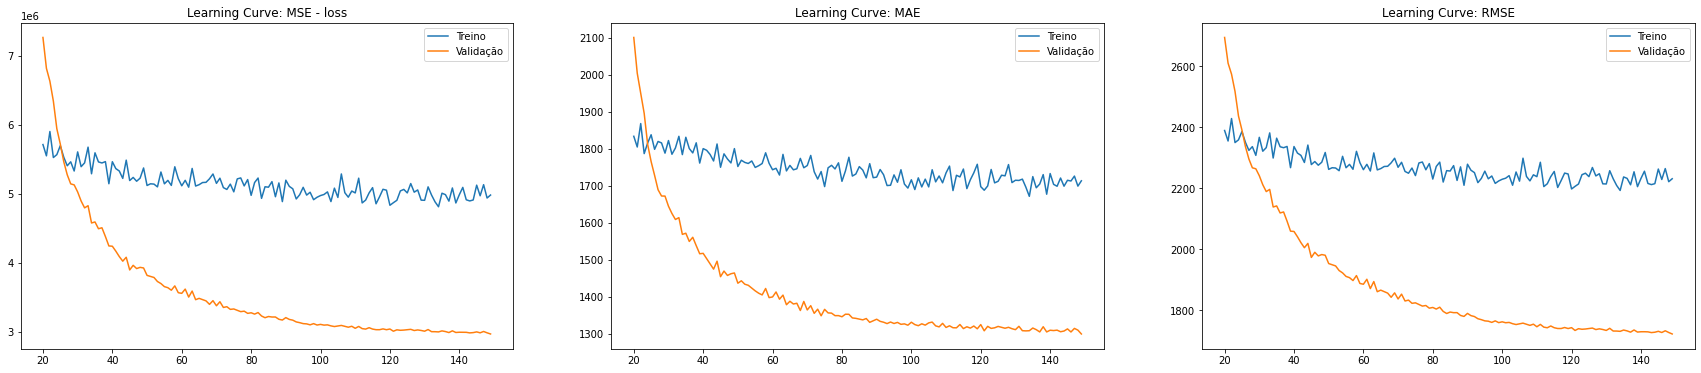

In [204]:
learning_curves(history=history, skip=20)

In [222]:
# evaluate one or more weekly forecasts against expected values
def evaluate_forecasts(actual, predicted):
	scores = list()
	# calculate an RMSE score for each week
	for i in range(actual.shape[1]):
		# calculate mse
		mse = mean_squared_error(actual.iloc[:,i], predicted[:,i])
		# calculate mape
		mape = mean_absolute_percentage_error(actual.iloc[:,i], predicted[:,i])
		
		# calculate rmse
		rmse = np.sqrt(mse)
		# store
		scores.append(rmse)
	# calculate overall RMSE
	s = 0
	for row in range(actual.shape[0]):
		for col in range(actual.shape[1]):
			s += (actual.iloc[row, col] - predicted[row,col])**2
	score = np.sqrt(s / (actual.shape[0] * actual.shape[1]))

	print(f'MSE: {mse}')
	print(f'MAPE: {mape*100}')
	return score, scores

evaluate_forecasts(df_target.loc[train_pred_data_week.index].iloc[:,0:5],pred_list[0])

MSE: 5174006.190002161
MAPE: 5.468279798020141


(1921.7215118941785,
 [1407.217714719967,
  1747.8029546293035,
  1940.4289731783733,
  2119.131942942532,
  2274.6441897585128])

In [223]:
def plot_pred(date_list, pred_list, df_target=df_target, baseline=False):

    colors = ['orange', 'green', 'purple']
    _,ax=plt.subplots(figsize=(20,35), ncols=1, nrows=5)
    extra = plt.Rectangle((0, 0), 0, 0, fc="none", fill=False, ec='none', linewidth=0)

    if baseline == True:
        sns.lineplot(x = df_target['Data'],
                y = df_target['Média Móvel'], 
                ax=np.ravel(ax)[0],
                color='black')


    for x in range(0,5):
        # plot measured data
        sns.lineplot(x = df_target['Data'], 
                    y = df_target[f'Semana {x+1}'], 
                    ax=np.ravel(ax)[x], 
                    color = 'teal')

        # plot predicted data
        for date,pred,color in zip(date_list, 
                                pred_list,
                                colors): 
            sns.lineplot(x = date[:].shift(x),
                        y = pred[:,x], 
                        ax=np.ravel(ax)[x],
                        color=color)
                        

        np.ravel(ax)[x].set_title(f'Carga real vs Predição em todo o período - Semana {x+1}')
        # np.ravel(ax)[x].legend(['Real','Previsão no treino','Previsão na validação','Previsão no teste'], loc='upper left')

        
        scores = (r"MAE Train ={:.0f}"+'\n'+r"MAE val ={:.0f}"+"\n"+r"MAE test ={:.0f}").format(
                tf.keras.metrics.mean_absolute_error(df_target[f'Semana {x+1}'].loc[np.array(date_list[0].index)],
                                                    pred_list[0][:,x]).numpy(),
                tf.keras.metrics.mean_absolute_error(df_target[f'Semana {x+1}'].loc[np.array(date_list[1].index)],
                                                    pred_list[1][:,x]).numpy(),
                tf.keras.metrics.mean_absolute_error(df_target[f'Semana {x+1}'].loc[np.array(date_list[2].index)],
                                                    pred_list[2][:,x]).numpy() 
                                                                                                )
        np.ravel(ax)[x].legend([extra], [scores], loc='lower right')
    plt.show()

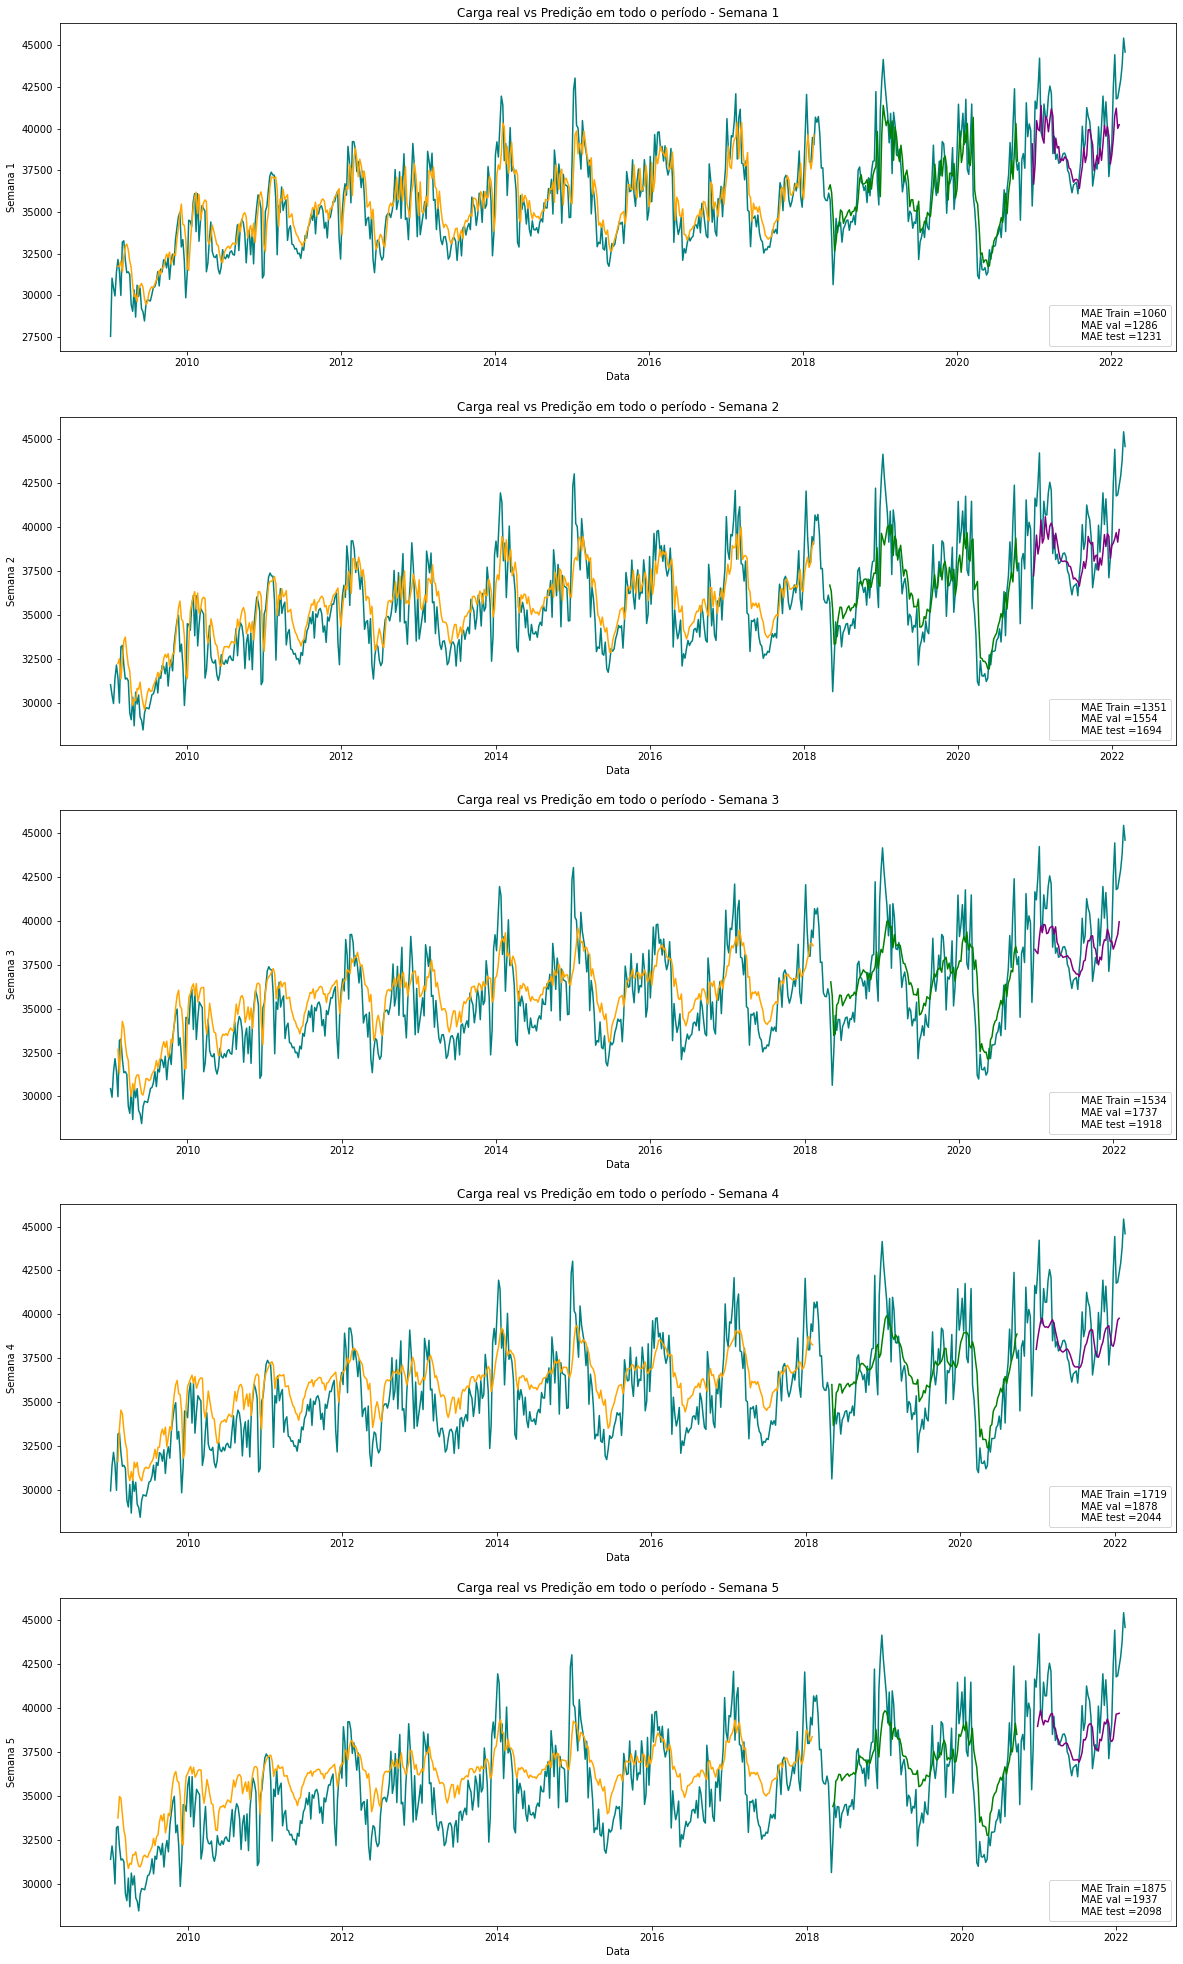

In [224]:
plot_pred(pred_list=pred_list, date_list=date_list, df_target=df_target, baseline=False)

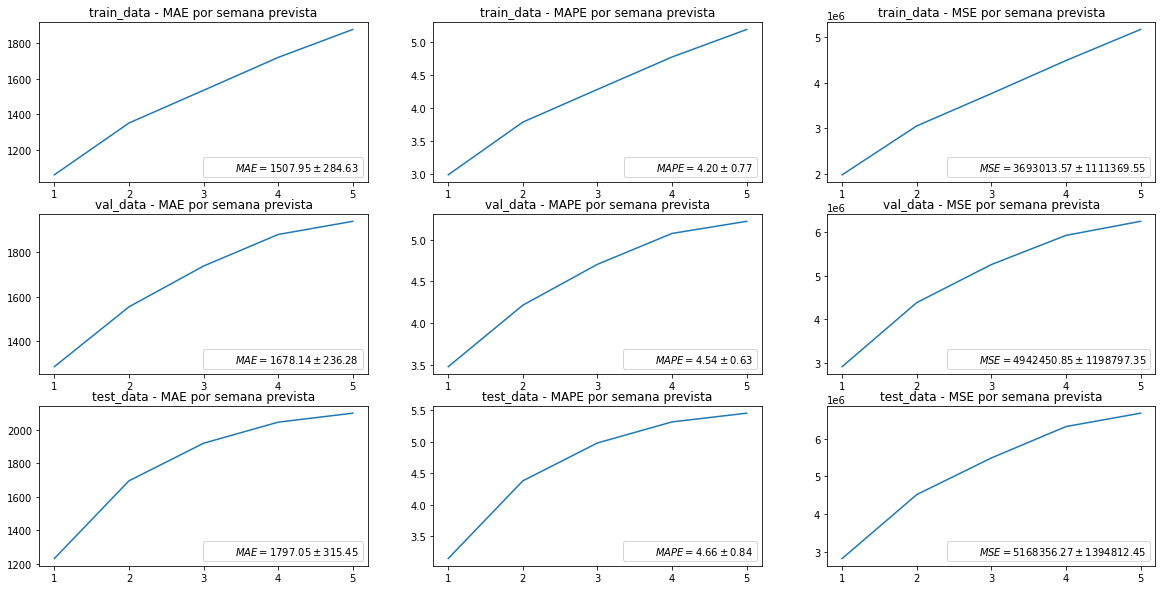

In [216]:
def metrics_semana(df_target, pred_list,date_list):
    name_dict = {'0':'train_data',
                '1':'val_data',
                '2': 'test_data'}

    fig, ax = plt.subplots(figsize=(20,10),ncols=3,nrows=3)

    for [i,df_loop,data_week] in zip([0,1,2],pred_list, date_list):

        mae_list = []
        mape_list = []
        mse_list = []

        for x in range(0,5):
            #print(f"MAE train_pred Semana {i+1}:  {mean_absolute_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])}")
            mae_list.append(mean_absolute_error(df_loop[:,x], 
                                                df_target[f'Semana {x+1}'].loc[np.array(data_week.index)]))
        for x in range(0,5):
            #print(f"MAPE train_pred Semana {i+1}: {mean_absolute_percentage_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])*100}")
            mape_list.append(mean_absolute_percentage_error(df_loop[:,x], 
                                                            df_target[f'Semana {x+1}'].loc[np.array(data_week.index)])*100)
        for x in range(0,5):
            #print(f"MSE train_pred Semeana {i+1}: {mean_squared_error(train_pred[:,i], df_target[5 : int(len(df_target)*0.7)-4].iloc[:,i])}")                
            mse_list.append(mean_squared_error(df_loop[:,x], df_target[f'Semana {x+1}'].loc[np.array(data_week.index)]))
        

        # rectangle to print the metrics mean and std over it 
        extra = plt.Rectangle((0, 0), 0, 0, fc="none", fill=False, ec='none', linewidth=0)
        # plot MAE by week
        sns.lineplot(x=range(1,6),y=mae_list, ax=ax[i,0])
        ax[i,0].set_title(f'{name_dict[str(i)]} - MAE por semana prevista')
        ax[i,0].set_xticks([1,2,3,4,5])
        scores = (r'$MAE={:.2f} \pm {:.2f}$').format(np.mean(mae_list),np.std(mae_list))
        ax[i,0].legend([extra], [scores], loc='lower right')
        # plot mape by week
        sns.lineplot(x=range(1,6),y=mape_list, ax=ax[i,1])
        ax[i,1].set_title(f'{name_dict[str(i)]} - MAPE por semana prevista')
        ax[i,1].set_xticks([1,2,3,4,5])
        scores = (r'$MAPE={:.2f} \pm {:.2f}$').format(np.mean(mape_list),np.std(mape_list))
        ax[i,1].legend([extra], [scores], loc='lower right')
        # plot MSE by week
        sns.lineplot(x=range(1,6),y=mse_list, ax=ax[i,2])
        ax[i,2].set_title(f'{name_dict[str(i)]} - MSE por semana prevista')
        ax[i,2].set_xticks([1,2,3,4,5])
        scores = (r'$MSE={:.2f} \pm {:.2f}$').format(np.mean(mse_list),np.std(mse_list))
        ax[i,2].legend([extra], [scores], loc='lower right')

    plt.show()


metrics_semana(df_target, pred_list,date_list)

# metrics_df = pd.DataFrame({'MAE': mae_list, 'MAPE':mape_list, 'MSE': mse_list})
# metrics_df.index = ['Semana 1','Semana 2','Semana 3','Semana 4','Semana 5']
# metrics_df

# Residual Analysis

In [217]:
def plot_res(df_target,pred_list, date_list):
    # variation from one week to the next
    res_baseline = df_target['Resíduo'] #- df_target['Resíduo'].mean())/df_target['Resíduo'].max()
    # prediction residues
    colors = ['orange', 'green', 'purple']


    fig, ax =plt.subplots(figsize=(20,8))
    # diferença normalizada entre semanas consecutivas
    #sns.lineplot(y=res_baseline, x=df_target['Data'], ax=ax)

    for pred, date, color in zip(pred_list,date_list,colors):
        
        res_pred = pred[:,0] - df_target[f'Semana 1'].loc[np.array(date.index)]
        sns.lineplot(y=res_pred, x=df_target['Data'], ax=ax, color= color)

    ax.set_title("Resíduo - Semana 1")
    ax.legend('')
    plt.show()

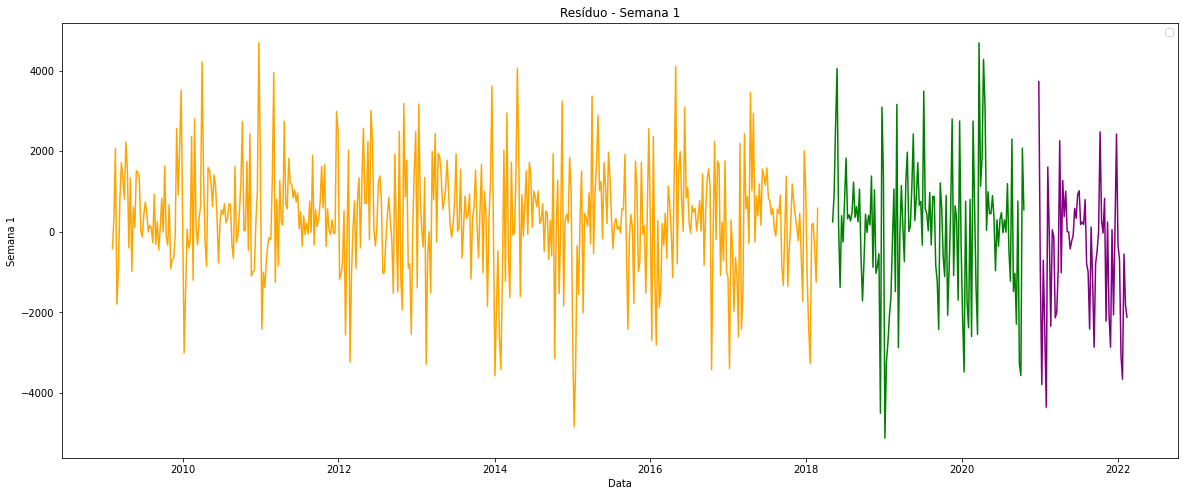

In [218]:
plot_res(df_target,pred_list, date_list)